# NFL Data Analysis Example

This notebook shows how to connect to the NFL database and perform basic analysis.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Connect to the NFL database
db_path = Path('../data/nfl.duckdb')
conn = duckdb.connect(str(db_path))

print(f"Connected to database: {db_path}")
print("Database connection established successfully!")

Connected to database: ../data/nfl.duckdb
Database connection established successfully!


In [3]:
# parameters
down = 3
season = 2025
play_type = 'pass'
ydstogo = (0,100)

q = f"""

with success as (
select posteam,
        down,
        season,
        ydstogo,
        play_type,
            epa > 0 as success
 from pbp 
        where 1=1
            and epa is not null
                            and down = {down}
                and season = {season}
               -- and play_type = '{play_type}'
                and ydstogo between {ydstogo[0]} and {ydstogo[1]}
            )

            select posteam, 
            down,
            season,
            sum(success) / count(*) as success_rate,
            avg(ydstogo) as avg_ydstogo,
            rank() over (order by sum(success) / count(*) desc) as rank
            from success
            where 1=1

            group by all
            order by success_rate desc
            
            
            """
pd.read_sql(q,conn)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
df = pd.read_sql_query(q, conn)
#df.head()

df.head()

median = df['success_rate'].median()

q75 = df['success_rate'].quantile(0.75)
q25 = df['success_rate'].quantile(0.25)

In [ ]:
get_df(query, down, season, play_type, ydstogo):
    

In [4]:
def rank_plot(df
            ,selected_team
            ,color='Blue'):


    plt.figure(figsize=(3, 4.5))
    plt.rcParams.update({'font.size': 12,
                         'font.family': 'Times New Roman',})  # Set base font size
    # Create colors array - blue for selected team, gray for others
    colors = [color if team == selected_team else 'gray' for team in df['posteam']]

    # Create horizontal dot plot with team names on y-axis
    plt.scatter(df['success_rate'], range(len(df)), c=colors, s=20)

    # Add vertical lines for quartiles
    plt.axvline(x=q25
                , color='red'
                , linestyle='--'
                , alpha=0.7
                , linewidth=.5
                , label=f'Q1 ({q25:.3f})')
    plt.axvline(x=median
                , color='gray'
                , linestyle='--'
                , alpha=0.7
                , linewidth=.5
                , label=f'Median ({median:.3f})')
    plt.axvline(x=q75
                , color='green'
                , linestyle='--'
                , alpha=0.7
                , linewidth=.5
                , label=f'Q3 ({q75:.3f})')

    # Set y-axis labels with colors
    plt.yticks(range(len(df)), df['posteam'])
    plt.xlabel('Success rate')
    plt.title(f'{season} Success Rate - {down} Down, {play_type} ')
    plt.gca().invert_yaxis()  # Reverse order so best is on top
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.yticks(fontsize=8)

    return plt

<module 'matplotlib.pyplot' from '/Users/chris.fenton/projects/nfl_analysis/nfl_env/lib/python3.9/site-packages/matplotlib/pyplot.py'>

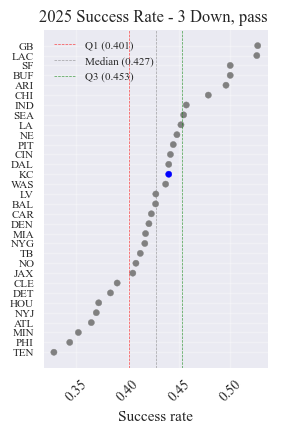

In [6]:
rank_plot(df,'KC')



### things to do:
- make this a function that takes down and team paramaters


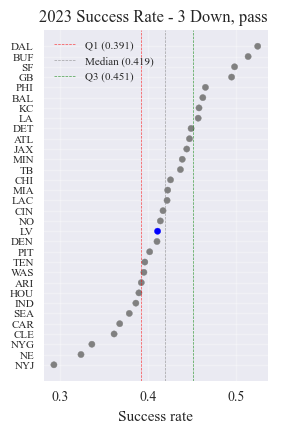

In [128]:
selected_team = 'LV'
color = 'blue'

# Create horizontal dot plot with team names on y-axis
plt.figure(figsize=(3, 4.5))
plt.rcParams.update({'font.size': 12,
'font.family': 'Times New Roman',})  # Set base font size
# Create colors array - blue for selected team, gray for others
colors = [color if team == selected_team else 'gray' for team in df['posteam']]

# Plot the dots
plt.scatter(df['success_rate'], range(len(df)), c=colors, s=20)

# Add vertical lines for quartiles
plt.axvline(x=q25
            , color='red'
            , linestyle='--'
            , alpha=0.7
            , linewidth=.5
            , label=f'Q1 ({q25:.3f})')
plt.axvline(x=median, color='gray', linestyle='--', alpha=0.7, linewidth=.5, label=f'Median ({median:.3f})')
plt.axvline(x=q75, color='green', linestyle='--', alpha=0.7, linewidth=.5, label=f'Q3 ({q75:.3f})')

# Set y-axis labels with colors
plt.yticks(range(len(df)), df['posteam'])
plt.xlabel('Success rate')
plt.title(f'{season} Success Rate - {down} Down, {play_type} ')
plt.gca().invert_yaxis()  # Reverse order so best is on top
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.yticks(fontsize=8)

plt.show()